In [12]:
# @title Install

# !pip uninstall -y tensorflow jax jaxlib

# !pip install pytorch-ignite
# !pip install ipynbname
# !pip install lightning
# !pip install torch_tb_profiler
# !pip install colormaps
# !pip install captum

In [13]:
# @title Importing

from __future__ import annotations

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.utils.tensorboard import SummaryWriter
from torch.profiler import schedule
import torchmetrics
from ignite.engine import Events
from ignite.metrics import Metric, Loss
from ignite.handlers import global_step_from_engine, EarlyStopping
from torch.optim.lr_scheduler import _LRScheduler, ReduceLROnPlateau, CosineAnnealingWarmRestarts, ChainedScheduler
from ignite.contrib.handlers import TensorboardLogger
from ignite.contrib.handlers.tensorboard_logger import *
from ignite.exceptions import NotComputableError

import lightning as L
import pytorch_lightning as pl
from pytorch_lightning.loggers import TensorBoardLogger
from lightning.pytorch.callbacks import ModelCheckpoint, ModelSummary
from lightning.pytorch.callbacks.early_stopping import EarlyStopping
from lightning.pytorch.profilers import SimpleProfiler, PyTorchProfiler
from lightning.pytorch.utilities.warnings import PossibleUserWarning

from torch.optim.lr_scheduler import SequentialLR

from captum.attr import Saliency, IntegratedGradients, Occlusion, GradientShap

from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import FastICA

import statsmodels.api as sm
from statsmodels.multivariate.factor_rotation import promax

import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.cm import ScalarMappable
from matplotlib import colors
import matplotlib.colors as mcolors
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Patch
import colormaps as cmaps
import plotly.graph_objects as go

from tqdm.auto import tqdm

import seaborn as sns

from scipy import stats
from scipy.stats import norm, ttest_rel
import scipy.io as sio
from scipy.interpolate import griddata

from joblib import Parallel, delayed

import numpy as np
import pandas as pd
import datetime
import time
import os
import sys
import glob
import ipynbname
import pickle
import json
import math
import warnings
import copy
import logging

logging.getLogger("lightning.pytorch").setLevel(logging.ERROR)
logging.getLogger("pytorch_lightning").setLevel(logging.ERROR)

warnings.filterwarnings("ignore", category=PossibleUserWarning)
warnings.filterwarnings("ignore", message=".*does not have many workers.*")
warnings.filterwarnings("ignore", message=r".*Checkpoint directory .* exists and is not empty.*", category=UserWarning, module=r"lightning\.pytorch\.callbacks\.model_checkpoint")
seed = 1
torch.manual_seed(seed)
np.random.seed(seed)
rng = np.random.default_rng(seed)

torch.set_float32_matmul_precision("high")
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
# @title Configuration

class DotDict(dict):
    def __init__(self, d=None):
        super().__init__()
        if d:
            for k, v in d.items():
                self[k] = self._wrap(v)

    def _wrap(self, value):
        if isinstance(value, dict):
            return DotDict(value)
        if isinstance(value, list):
            return [self._wrap(v) for v in value]
        return value

    def __getattr__(self, name):
        try:
            return self[name]
        except KeyError:
            raise AttributeError(name)

    def __setattr__(self, name, value):
        self[name] = self._wrap(value)

    def __delattr__(self, name):
        try:
            del self[name]
        except KeyError:
            raise AttributeError(name)

    def to_dict(self):
        out = {}
        for k, v in self.items():
            if isinstance(v, DotDict):
                out[k] = v.to_dict()
            elif isinstance(v, list):
                out[k] = [x.to_dict() if isinstance(x, DotDict) else x for x in v]
            else:
                out[k] = v
        return out

    def __deepcopy__(self, memo):
        return DotDict(copy.deepcopy(self.to_dict(), memo))


Conf = DotDict({
    "run_id": 1,
    "paths": {
        "data": "data.mat",
        "logs": "/lightning_logs",
    },
    "session_idx": 18,
    "device": device,
    "training": {
        "batch_size": 32,
        "max_epoch": 1000,
        "min_delta": 1e-5,
        "patience": 15,
    },
    "model_type": {
        "name": "mean",
        "mean": {
            "n_hidden": 32,
            "n_heads": 2,
            "n_layers": 1,
            "nonlinearity": "gelu",
            "dropout": 0.2,
        },
        "cov": {
            "n_latent": 64,
            "n_seq": None,
            "n_hidden": 8,
            "n_heads": 2,
            "n_layers": 1,
            "nonlinearity": "gelu",
            "dropout": 0.2,
        },
    },
    "optimization": {
        "optimizer_type": {
            "name": "Adam",
            "Adam": {
                "lr": 0.01,
                "weight_decay": 0.0001,
            },
            "AdamW": {
                "lr": 0.01,
                "weight_decay": 0.0001,
            },
        },
        "scheduler_type": {
            "name": "Reduce",
            "Reduce": {
                "factor": 0.5,
                "patience":5,
                "min_lr": 1e-10,
            },
            "Cosine": {
                "T_mult": 1,
                "eta_min": 1e-5,
                "last_epoch": -1,
            }
        }
    }
})

In [15]:
# @title Helpers

class Anscombe(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x):
        return 2.0 * torch.sqrt(x + 3.0 / 8.0)

    def inv(self, x):
        return (x / 2.0) ** 2 - 3.0 / 8.0

     
class NeuralDataset(Dataset):
    def __init__(self, x_position_vars, x_dense_vars, x_sparse_vars, Y, mean):
        self.x_position_vars = torch.tensor(x_position_vars, dtype=torch.float32).transpose(1, 2)
        self.x_dense_vars = torch.tensor(x_dense_vars, dtype=torch.float32)
        self.x_sparse_vars = torch.tensor(x_sparse_vars, dtype=torch.float32).round().long()

        Y_tensor = torch.tensor(Y, dtype=torch.float32).transpose(1, 2)
        anscombe = Anscombe()
        Y_anscombed = anscombe.forward(Y_tensor)
        self.Y = Y_anscombed - mean.cpu()
        
    def __len__(self):
        return self.x_position_vars.size(0)

    def __getitem__(self, idx):
        X = (self.x_position_vars[idx], self.x_dense_vars[idx], self.x_sparse_vars[idx])
        y = self.Y[idx]
        return X, y


class MetricHistory(L.Callback):
    def __init__(self):
        super().__init__()
        self.history = {
            "epoch": [],
            "train_loss_epoch": [],
            "valid_loss_epoch": [],
            "train_correlation": [],
            "valid_correlation": [],
        }

    def on_validation_epoch_end(self, trainer, pl_module):
        metrics = trainer.callback_metrics

        self.history["epoch"].append(int(trainer.current_epoch))
        self.history["train_loss_epoch"].append(
            float(metrics["train_loss_epoch"].detach().cpu()) if "train_loss_epoch" in metrics else np.nan
        )
        self.history["valid_loss_epoch"].append(
            float(metrics["valid_loss_epoch"].detach().cpu()) if "valid_loss_epoch" in metrics else np.nan
        )
        self.history["train_correlation"].append(
            float(metrics["train_correlation"].detach().cpu()) if "train_correlation" in metrics else np.nan
        )
        self.history["valid_correlation"].append(
            float(metrics["valid_correlation"].detach().cpu()) if "valid_correlation" in metrics else np.nan
        )


class MVNNLLLoss(nn.Module):
    def __init__(self, reduction="mean"):
        super().__init__()

    def forward(self, out, y):
        mean, L = out
        
        if not torch.is_tensor(mean):
            mean = torch.stack(list(mean), dim=0)
        if not torch.is_tensor(y):
            y = torch.stack(list(y), dim=0)
        if not torch.is_tensor(L):
            L = torch.stack(list(L), dim=0)

        B = mean.shape[0]
        mean = mean.reshape(B, -1)
        y = y.reshape(B, -1)
        D = mean.shape[1]

        if L.dim() == 2:
            L = L.unsqueeze(0).expand(B, -1, -1)

        diff = (y - mean).unsqueeze(-1)
        sol = torch.linalg.solve_triangular(L, diff, upper=False).squeeze(-1)
        maha = (sol * sol).sum(dim=-1)
        logdet = 2.0 * torch.log(torch.diagonal(L, dim1=-2, dim2=-1)).sum(dim=-1)
        log_prob = -0.5 * (D * math.log(2.0 * math.pi) + logdet + maha)
        loss = (-log_prob / D)
        
        return loss


def build_lit_model(Conf, mean_model, cov_model, fold_idx, enable_progress_bar_epoch):
    run_name = f"{mean_model}-mean-{cov_model}-cov"
    ckpt_dir = f"{Conf.paths.logs}/{run_name}/fold_{fold_idx}"

    logger = TensorBoardLogger(
        save_dir=Conf.paths.logs,
        name=run_name,
    )
    checkpoint_callback = ModelCheckpoint(
        dirpath=ckpt_dir,
        filename='model-{epoch:02d}-{valid_loss_epoch:.2f}',
        monitor='valid_loss_epoch',
        mode='min',
        save_top_k=3,
        save_last=True,
        verbose=False,
    )
    early_stop_callback = EarlyStopping(
        monitor='valid_loss_epoch',
        min_delta=Conf.training.min_delta,
        patience=Conf.training.patience,
        verbose=True,
        mode='min',
    )
    metric_history_callback = MetricHistory()
    
    trainer = L.Trainer(
        max_epochs=Conf.training.max_epoch,
        accelerator="gpu" if Conf.device.type == "cuda" else "cpu",
        devices=1,
        precision="16-mixed",
        num_sanity_val_steps=0,
        logger=False,
        callbacks=[early_stop_callback, metric_history_callback],
        enable_progress_bar=enable_progress_bar_epoch,
        enable_checkpointing=False,
        enable_model_summary=False,
        detect_anomaly=False,
        check_val_every_n_epoch=1,
    )
    
    lit_model = LitModel(Conf, mean_model, cov_model).to(Conf.device)
    trainer.metric_history_callback = metric_history_callback
    
    return trainer, lit_model


def train_folds(Conf, train_loader_folds, valid_loader_folds, mean_model, cov_model, n_seq, base_lit_models=None, enable_progress_bar_epoch=False, enable_progress_bar_fold=True):
    
    if enable_progress_bar_fold:
        bar = tqdm(total=len(train_loader_folds), desc="Fold", position=0, leave=True, dynamic_ncols=True)

    Conf_ = copy.deepcopy(Conf)
    Conf_.model_type.cov.n_seq = n_seq

    lit_models = []
    trainers = []
    metrics = []
    for fold_idx, (train_loader, valid_loader) in enumerate(
        zip(train_loader_folds, valid_loader_folds), start=0 
    ):
        trainer, lit_model = build_lit_model(Conf_, mean_model, cov_model, fold_idx, enable_progress_bar_epoch)

        if base_lit_models is not None:
            base_model_state_dict = base_lit_models[fold_idx].full_model.mean_model.state_dict()
            lit_model.full_model.mean_model.load_state_dict(base_model_state_dict, strict=True)
            for p in lit_model.full_model.mean_model.parameters():
                p.requires_grad = False
    
        trainer.fit(lit_model, train_loader, valid_loader)
        lit_models.append(lit_model)
        trainers.append(trainer)

        metric = {k: float(v.detach().cpu()) for k, v in trainer.callback_metrics.items() if torch.is_tensor(v)}
        metrics.append(metric)
        
        valid_loss_epoch = np.mean([metric["valid_loss_epoch"] for metric in metrics if "valid_loss_epoch" in metric])
        valid_correlation = np.mean([metric["valid_correlation"] for metric in metrics if "valid_correlation" in metric])
        train_loss_epoch = np.mean([metric["train_loss_epoch"] for metric in metrics if "train_loss_epoch" in metric])
        train_correlation = np.mean([metric["train_correlation"] for metric in metrics if "train_correlation" in metric])

        if enable_progress_bar_fold:
            bar.set_description("Fold:")
            bar.set_postfix({
                "valid_loss_fold": f"{valid_loss_epoch:.4f}",
                "valid_corr_fold": f"{valid_correlation:.4f}",
                "train_loss_fold": f"{train_loss_epoch:.4f}",
                "train_corr_fold": f"{train_correlation:.4f}",
            })
            bar.update(1)
        
    return lit_models, trainers


def predict_loader(Conf, lit_model, loader, Y_mean, varient):
    device = Conf.device
    lit_model = lit_model.to(device)
    lit_model.eval()
    conditional_gaussian = ConditionalGaussian(Conf, varient).to(device)
    anscombe = Anscombe().to(device)
    Y = []
    Y_hat = []

    for batch in loader:
        x, y = batch
        x = tuple(t.to(device, non_blocking=True) for t in x)
        y = y.to(device, non_blocking=True)
        mean, L = lit_model.forward(x)
        cov = L @ L.transpose(-1, -2)

        y_hat = torch.stack(
            [conditional_gaussian.predict(mean_sample, cov_sample, y_sample) for mean_sample, cov_sample, y_sample in zip(mean, cov, y)],
            dim=0
        )
        y = anscombe.inv(y + Y_mean)
        y_hat = anscombe.inv(y_hat + Y_mean)        

        Y.append(y)
        Y_hat.append(y_hat)

    Y = torch.cat(Y, dim=0).detach().cpu().numpy()
    Y_hat = torch.cat(Y_hat, dim=0).detach().cpu().numpy()

    return Y, Y_hat


compute_corr = lambda y, y_hat: np.corrcoef(y.flatten(), y_hat.flatten())[0, 1]
compute_r2 = lambda y, y_hat: 1 - np.sum((y.flatten() - y_hat.flatten()) ** 2) / np.sum((y.flatten() - np.mean(y.flatten())) ** 2)
                                          
def compute_metrics(Conf, Y, Y_hat):
    n_units = Conf.data.n_units
    corr = []
    r2 = []
    for unit_idx in range(n_units):
        unit_corr = compute_corr(Y[:, :, unit_idx], Y_hat[:, :, unit_idx])
        unit_r2 = compute_r2(Y[:, :, unit_idx], Y_hat[:, :, unit_idx])
        corr.append(unit_corr)
        r2.append(unit_r2)
    return corr, r2


def predict_folds(Conf, lit_model_folds, loader_folds, Y_mean_folds, varient):
    Y_folds = []
    Y_hat_folds = []
    for _, (lit_model, loader, Y_mean) in enumerate(zip(lit_model_folds, loader_folds, Y_mean_folds)):
        Y, Y_hat = predict_loader(Conf, lit_model, loader, Y_mean, varient)
        Y_folds.append(Y)
        Y_hat_folds.append(Y_hat)

    return Y_folds, Y_hat_folds


def compute_metrics_folds(Conf, Y_folds, Y_hat_folds):
    corr_folds = []
    r2_folds = []
    for Y, Y_hat, in zip(Y_folds, Y_hat_folds):
        corr, r2 = compute_metrics(Conf, Y, Y_hat)
        corr_folds.append(corr)
        r2_folds.append(r2)

    return corr_folds, r2_folds




In [16]:
# @title Plots

def _save_figure(
    fig,
    title,
    save_path,
    ext=".png",
    **savefig_kwargs
):

    if save_path is None:
        return

    if os.path.isdir(save_path) or save_path.endswith(os.sep):
        os.makedirs(save_path, exist_ok=True)
        filename = os.path.join(save_path, f"{title}{ext}")
    else:
        os.makedirs(os.path.dirname(save_path) or ".", exist_ok=True)
        filename = save_path

    fig.savefig(filename, **savefig_kwargs)


In [17]:
# @title Model

class Model(nn.Module):
    def __init__(self, Conf=None, **kwargs):
        super().__init__()
        self.n_position_vars = Conf.data.n_position_vars
        self.n_dense_vars = Conf.data.n_dense_vars
        self.n_sparse_vars = Conf.data.n_sparse_vars
        self.n_vars = Conf.data.n_vars
        self.n_bins = Conf.data.n_bins
        self.n_units = Conf.data.n_units
        self.device = Conf.device


class Time2Vec(nn.Module):
    def __init__(self, n_hidden):
        super().__init__()
        self.w0 = nn.Parameter(torch.randn(1))
        self.b0 = nn.Parameter(torch.randn(1))
        self.w = nn.Parameter(torch.randn(n_hidden - 1))
        self.b = nn.Parameter(torch.randn(n_hidden - 1))

    def forward(self, t):
        t = t.unsqueeze(-1)
        linear = self.w0 * t + self.b0
        periodic = torch.sin(self.w * t + self.b)
        return torch.cat([linear, periodic], dim=-1)


class Time2VecPositionalEncoding(nn.Module):
    def __init__(self, n_hidden):
        super().__init__()
        self.n_hidden = n_hidden
        self.t2v = Time2Vec(n_hidden)

    def forward(self, n_bins, device):
        t = torch.arange(n_bins, device=device).float()
        enc = self.t2v(t)
        return enc.unsqueeze(0)


class Transformer():
    def __init__(self, Conf=None, **kwargs):
        super().__init__(Conf=Conf, **kwargs)
        self.n_hidden = Conf.model_type[Conf.model_type.name].n_hidden
        self.n_heads = Conf.model_type[Conf.model_type.name].n_heads
        self.n_layers = Conf.model_type[Conf.model_type.name].n_layers
        self.nonlinearity = Conf.model_type[Conf.model_type.name].nonlinearity
        self.dropout = Conf.model_type[Conf.model_type.name].dropout

        self.sparse_var_embeds = nn.ModuleList([
            nn.Embedding(2, 1) for _ in range(self.n_sparse_vars)
        ])
        
        self.dense_vars_proj = nn.Linear(self.n_dense_vars, self.n_dense_vars)
        self.position_vars_proj = nn.Linear(self.n_position_vars, self.n_position_vars)
        self.vars_proj = nn.Linear(self.n_vars, self.n_hidden)
        
        self.positional_encoding = Time2VecPositionalEncoding(self.n_hidden)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=self.n_hidden,
            nhead=self.n_heads,
            dim_feedforward=self.n_hidden * 4,
            dropout=self.dropout,
            activation=self.nonlinearity,
            batch_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=self.n_layers)
        self.dropout_layer = nn.Dropout(self.dropout)
        

    def forward_transformer(self, x):
        x_position_vars, x_dense_vars, x_sparse_vars = x
        
        sparse_vars = torch.stack([self.sparse_var_embeds[i](x_sparse_vars[:, i]) for i in range(x_sparse_vars.size(1))], dim=1).squeeze(-1)
        sparse_vars = sparse_vars.unsqueeze(1).expand(-1, self.n_bins, -1)
        dense_vars = self.dense_vars_proj(x_dense_vars).unsqueeze(1)
        dense_vars = dense_vars.expand(-1, self.n_bins, -1)
        position_vars = self.position_vars_proj(x_position_vars)
        stacked = torch.cat([position_vars, dense_vars, sparse_vars], dim=2)
        stacked = self.vars_proj(stacked)
        
        pos_enc = self.positional_encoding(self.n_bins, stacked.device)
        combined = stacked + pos_enc
        transformed = self.transformer_encoder(combined)
        transformed = self.dropout_layer(transformed)
        return transformed


class MeanModel(Model):
    def __init__(self, Conf):
        super().__init__(Conf)


class BaselineMeanModel(MeanModel):
    def __init__(self, Conf):
        super().__init__(Conf)
        self.theta = nn.Parameter(torch.empty(self.n_bins, self.n_units, device=self.device))

        with torch.no_grad():
            nn.init.normal_(self.theta, mean=0, std=1e-1)
            
    def forward(self, x):
        batch_size = x[0].size(0)
        mean = self.theta
        return mean.unsqueeze(0).expand(batch_size, -1, -1)


class ConditionalMeanModel(Transformer, MeanModel):
    def __init__(self, Conf):
        Conf_ = copy.deepcopy(Conf)
        Conf_.model_type.name = "mean"
        super().__init__(Conf=Conf_)

        self.output_size = self.n_units
        self.head = nn.Linear(self.n_hidden, self.output_size)

    def forward(self, x):
        transformed = self.forward_transformer(x)
        mean = self.head(transformed)
        return mean
             

class CovModel(Model):
    def __init__(self, Conf):
        super().__init__(Conf)
        self.n_seq = Conf.model_type.cov.n_seq
        self.n_latent = Conf.model_type.cov.n_latent
        
        self.register_buffer("I", torch.eye(self.n_bins * self.n_units, dtype=torch.float32, device=self.device))
        self.length_scales = nn.Parameter(torch.empty(self.n_latent, device=self.device))
        self.noise = nn.Parameter(torch.empty(self.n_bins, self.n_units, device=self.device))

        with torch.no_grad():
            ls0 = math.log(math.expm1(0.5))
            self.length_scales.fill_(ls0)
            nn.init.normal_(self.length_scales, mean=ls0, std=1)
            nn.init.normal_(self.noise, mean=-20.0, std=1)

    def kernel(self, fun, n_samples1, n_samples2, l):
        i_grid = torch.arange(n_samples1, dtype=torch.float32, device=l.device).view(-1, 1)
        j_grid = torch.arange(n_samples2, dtype=torch.float32, device=l.device).view(1, -1)
        return fun(i_grid, j_grid, l)

    def squared_exponential_kernel(self, x1, x2, l):
        distances = (x2 - x1).unsqueeze(0)
        frac = distances / l.unsqueeze(-1).unsqueeze(-1)
        return torch.exp(-0.5 * (frac**2))
    
    def build_covariance_matrix(self, lambda_matrix):
        if self.n_bins != self.n_seq:
            batch_size = lambda_matrix.size(0)
            lambda_matrix = lambda_matrix.permute(0, 2, 3, 1).reshape(batch_size, self.n_units * self.n_latent, self.n_seq)
            lambda_matrix = F.interpolate(lambda_matrix, size=self.n_bins, mode="linear", align_corners=True)
            lambda_matrix = lambda_matrix.view(batch_size, self.n_units, self.n_latent, self.n_bins).permute(0, 3, 1, 2).contiguous()
    
        l = F.softplus(self.length_scales)
        K = self.kernel(self.squared_exponential_kernel, self.n_bins, self.n_bins, l=l)
    
        blocks = torch.einsum('btok,kts,bsuk->btosu', lambda_matrix, K, lambda_matrix)
        cov = blocks.reshape(
            lambda_matrix.size(0),
            self.n_bins * self.n_units,
            self.n_bins * self.n_units
        )
    
        cov = cov + self.I.unsqueeze(0)
        noise_diag = torch.sigmoid(self.noise.flatten())
        cov.diagonal(dim1=-2, dim2=-1).add_(noise_diag)
    
        L = torch.linalg.cholesky(cov)
        return L


class IdentityCovModel(CovModel):
    def __init__(self, Conf):
        super().__init__(Conf)

    def forward(self, x):
        batch_size = x[0].size(0)
        L = self.I.unsqueeze(0).expand(batch_size, -1, -1)
        return L
            

class SharedCovModel(CovModel):
    def __init__(self, Conf):
        super().__init__(Conf)
        
        self.lambda_matrix = nn.Parameter(torch.empty(self.n_seq, self.n_units, self.n_latent, device=self.device))

        with torch.no_grad():
            nn.init.normal_(self.lambda_matrix, mean=0.0, std=1e-1)

    def forward(self, x):
        batch_size = x[0].size(0)
        L = self.build_covariance_matrix(self.lambda_matrix.unsqueeze(0)).squeeze(0)
        L = L.unsqueeze(0).expand(batch_size, -1, -1)
        return L


class ConditionalCovModel(Transformer, CovModel):
    def __init__(self, Conf):
        Conf_ = copy.deepcopy(Conf)
        Conf_.model_type.name = "cov"
        super().__init__(Conf=Conf_)

        self.output_size = self.n_units * self.n_latent
        self.head = nn.Linear(self.n_hidden, self.output_size)

    def forward(self, x):
        transformed = self.forward_transformer(x)

        if self.n_bins != self.n_seq:
            transformed = transformed.permute(0, 2, 1)
            transformed = F.interpolate(transformed, size=self.n_seq, mode='linear', align_corners=True)
            transformed = transformed.permute(0, 2, 1)

        out = self.head(transformed)
        lambda_matrix = out.view(out.size(0), self.n_seq, self.n_units, self.n_latent)
        L = self.build_covariance_matrix(lambda_matrix)
        return L


class FullModel(Model):
    def __init__(self, Conf, mean_model, cov_model):
        super().__init__(Conf)
        if mean_model == 'baseline':
            self.mean_model = BaselineMeanModel(Conf)
        elif mean_model == 'conditional':
            self.mean_model = ConditionalMeanModel(Conf)

        if cov_model == 'identity':
            self.cov_model = IdentityCovModel(Conf)
        elif cov_model == 'shared':
            self.cov_model = SharedCovModel(Conf)
        elif cov_model == 'conditional':
            self.cov_model = ConditionalCovModel(Conf)
    
    def forward(self, x):
        mean = self.mean_model(x)
        L = self.cov_model(x)
        return mean, L


class ConditionalGaussian(Model):
    def __init__(self, Conf, variant):
        super().__init__(Conf)
        self.variant = variant

    def predict(self, mean, cov, y, **kwargs):
        if self.variant == 'mean':
            return mean
        elif self.variant == 'past':
            return self.__predict_by_past(mean, cov, y)
        elif self.variant == 'others':
            return self.__predict_by_others(mean, cov, y)
        elif self.variant == 'past_and_others':
            return self.__predict_by_past_and_others(mean, cov, y)
        else:
            raise ValueError(f'Variant is not supported: {self.variant}')
    
    def __predict_by_past(self, mean, cov, y, max_t_past_prediction=None):
        y_flat = y.flatten()
        mean_flat = mean.flatten()
        conditioned_mean = mean.clone().reshape((-1, self.n_units))
    
        for t in range(1, conditioned_mean.shape[0]):
            conditioned_indices = torch.arange(t * self.n_units, device=mean.device).reshape(t, self.n_units).t()
            product_indices = torch.stack((
                conditioned_indices.flatten().repeat_interleave(t).reshape(self.n_units, t, t),
                conditioned_indices.unsqueeze(1).repeat(1, t, 1)
            ), dim=-1)
    
            row_indices = torch.arange(t * self.n_units, (t + 1) * self.n_units, device=mean.device)
            cross_cov = cov[row_indices.unsqueeze(-1), conditioned_indices].unsqueeze(1)
            partial_cov = cov[product_indices[..., 0], product_indices[..., 1]].reshape(self.n_units, t, t)
            diff = (y_flat[conditioned_indices] - mean_flat[conditioned_indices]).unsqueeze(-1)
    
            conditioned_mean[t] += torch.matmul(torch.matmul(cross_cov, torch.linalg.inv(partial_cov)), diff).reshape(self.n_units)
    
        return conditioned_mean
    
    def __predict_by_others(self, mean, cov, y):
        nr_others = self.n_units - 1
        y_flat = y.flatten()
        mean_flat = mean.flatten()
        conditioned_mean = mean.clone().reshape((-1, self.n_units))
    
        for t in range(conditioned_mean.shape[0]):
            time_indices = torch.arange(t * self.n_units, (t + 1) * self.n_units, device=mean.device)
            conditioned_indices = time_indices.unsqueeze(0).repeat(self.n_units, 1)
            conditioned_indices = conditioned_indices[~torch.eye(self.n_units, dtype=torch.bool, device=mean.device)].reshape(self.n_units, nr_others)
    
            product_indices = torch.stack((
                conditioned_indices.flatten().repeat_interleave(nr_others).reshape(self.n_units, nr_others, nr_others),
                conditioned_indices.unsqueeze(1).repeat(1, nr_others, 1)
            ), dim=-1)
    
            cross_cov = cov[time_indices.unsqueeze(-1), conditioned_indices].unsqueeze(1)
            partial_cov = cov[product_indices[..., 0], product_indices[..., 1]].reshape(self.n_units, nr_others, nr_others)
            diff = (y_flat[conditioned_indices] - mean_flat[conditioned_indices]).unsqueeze(-1)
    
            conditioned_mean[t] += torch.matmul(torch.matmul(cross_cov, torch.linalg.inv(partial_cov)), diff).reshape(self.n_units)
    
        return conditioned_mean
    
    def __predict_by_past_and_others(self, mean, cov, y, max_t_past_prediction=None):
        nr_others = self.n_units - 1
        y_flat = y.flatten()
        mean_flat = mean.flatten()
        conditioned_mean = mean.clone().reshape((-1, self.n_units))
    
        for t in range(conditioned_mean.shape[0]):
            nr_past_and_others = t + nr_others
    
            past_indices = torch.arange(t * self.n_units, device=mean.device).reshape(t, self.n_units).t()
            time_indices = torch.arange(t * self.n_units, (t + 1) * self.n_units, device=mean.device)
            others_indices = time_indices.unsqueeze(0).repeat(self.n_units, 1)
            others_indices = others_indices[~torch.eye(self.n_units, dtype=torch.bool, device=mean.device)].reshape(self.n_units, nr_others)
    
            conditioned_indices = torch.cat((past_indices, others_indices), dim=-1)
    
            product_indices = torch.stack((
                conditioned_indices.flatten().repeat_interleave(nr_past_and_others).reshape(self.n_units, nr_past_and_others, nr_past_and_others),
                conditioned_indices.unsqueeze(1).repeat(1, nr_past_and_others, 1)
            ), dim=-1)
    
            cross_cov = cov[time_indices.unsqueeze(-1), conditioned_indices].unsqueeze(1)
            partial_cov = cov[product_indices[..., 0], product_indices[..., 1]].reshape(self.n_units, nr_past_and_others, nr_past_and_others)
            diff = (y_flat[conditioned_indices] - mean_flat[conditioned_indices]).unsqueeze(-1)
    
            conditioned_mean[t] += torch.matmul(torch.matmul(cross_cov, torch.linalg.inv(partial_cov)), diff).reshape(self.n_units)
    
        return conditioned_mean


def eval_mean_model(module):
    if not any(p.requires_grad for p in module.full_model.mean_model.parameters()):
        module.full_model.mean_model.eval()


class LitModel(L.LightningModule):
    def __init__(self, Conf, mean_model, cov_model):
        super().__init__()
        self.save_hyperparameters(ignore=["optimizer_type", "scheduler_type", "data", "model_params"])        
        self.optimizer_name = Conf.optimization.optimizer_type.name
        self.optimizer_params = Conf.optimization.optimizer_type[self.optimizer_name]
        self.scheduler_name = Conf.optimization.scheduler_type.name
        if self.scheduler_name != None:
            self.scheduler_params = Conf.optimization.scheduler_type[self.scheduler_name]

        self.full_model = FullModel(Conf, mean_model, cov_model)
        self.mvn_nll_loss = MVNNLLLoss()
        self.anscombe = Anscombe()
     
    def forward(self, x):
        return self.full_model(x)

    def training_step(self, batch, batch_idx):
        x, y = batch
        x = tuple(t.to(self.device, non_blocking=True) for t in x)
        y = y.to(self.device, non_blocking=True)
        eval_mean_model(self)
        out = self(x)
        loss = self.mvn_nll_loss(out, y).mean()

        self.log("train_loss_step", loss, on_step=True, on_epoch=False, logger=False, prog_bar=False)
        self.log("train_loss_epoch", loss, on_step=False, on_epoch=True, logger=False, prog_bar=True)
        self.log("learning_rate_step", self.trainer.optimizers[0].param_groups[0]['lr'],
                on_step=False, on_epoch=True, logger=False)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        x = tuple(t.to(self.device, non_blocking=True) for t in x)
        y = y.to(self.device, non_blocking=True)
        eval_mean_model(self)
        out = self(x)
        loss = self.mvn_nll_loss(out, y).mean()

        self.log("valid_loss_epoch", loss, on_step=False, on_epoch=True, logger=False, prog_bar=True)

    def on_validation_epoch_end(self):
        loss = self.trainer.callback_metrics.get('valid_loss_epoch')
        if loss is not None and self.scheduler_name == 'CosineReduce':
            self.scheduler.step_on_plateau(loss.item())

    def configure_optimizers(self):
        params = [p for p in self.parameters() if p.requires_grad]

        if self.optimizer_name == "Adam":
            optimizer = torch.optim.Adam(
                params,
                lr=self.optimizer_params.lr,
                weight_decay=self.optimizer_params.weight_decay
            )
        elif self.optimizer_name == "AdamW":
            optimizer = torch.optim.AdamW(
                params,
                lr=self.optimizer_params.lr,
                weight_decay=self.optimizer_params.weight_decay
            )

        if self.scheduler_name == None:
            return optimizer

        elif self.scheduler_name == 'Reduce':
            scheduler = ReduceLROnPlateau(
                optimizer,
                mode='min',
                factor=self.scheduler_params.factor,
                patience=self.scheduler_params.patience,
                min_lr=self.scheduler_params.min_lr
            )
            return {
                'optimizer': optimizer,
                'lr_scheduler': {
                    'scheduler': scheduler,
                    'monitor': 'valid_loss_epoch',
                    'interval': 'epoch',
                    'frequency': 1
                }
            }

        elif self.scheduler_name == 'Cosine':
            scheduler = CosineAnnealingWarmRestarts(
                optimizer,
                T_0=1,
                T_mult=self.scheduler_params.T_mult,
                eta_min=self.scheduler_params.eta_min,
                last_epoch=self.scheduler_params.last_epoch
            )
            return {
                'optimizer': optimizer,
                'lr_scheduler': {
                    'scheduler': scheduler,
                    'interval': 'step',
                    'frequency': 1
                }
            }

In [18]:
data = sio.loadmat(Conf.paths.data, squeeze_me=True, struct_as_record=False)

session_name = data['session_names'][Conf.session_idx]
spikes = data['spikes'][Conf.session_idx]
position_vars = data['position_vars'][Conf.session_idx]
position_var_names = data['position_var_names']
task_vars = data['task_vars'][Conf.session_idx]
task_var_names = data['task_var_names']
events = data['events'][Conf.session_idx]
event_names = data['event_names']
unit_names = data['unit_names'][Conf.session_idx]
channel_names = data['channel_names'][Conf.session_idx]
unit_types = data['unit_types'][Conf.session_idx]
bin_size = data['bin_size']
bin_times = data['bin_times']
variable_names = np.concatenate((position_var_names, task_var_names), axis=0)

spikes  = np.transpose(spikes, (1, 0, 2)) * 0.2
position_vars  = np.transpose(position_vars, (1, 0, 2))
task_vars = np.transpose(task_vars, (1, 0))

dense = [0, 1, 2, 3]
sparse = [4, 5, 6]

print(f"session_idx = {Conf.session_idx}, session_name = {session_name}")
print(f'task_var_names = {task_var_names}')
print(f'spikes.shape = {spikes.shape}')

session_idx = 15, session_name = 109
task_var_names = ['tunp' 'tslp' 'rew_rate' 'rew_ratio' 'rew' 'choice' 'last_choice']
spikes.shape = (783, 80, 26)


In [ ]:
units_to_remove = [14, 15, 20, 82, 91, 175]
units_to_remove = [23, 52, 61, 105, 106, 116, 118, 133, 139, 149, 150, 165, 166]
units_mask_delete = np.isin(unit_names, units_to_remove)
unit_names = unit_names[~units_mask_delete]
spikes = spikes[:, ~units_mask_delete]

In [21]:
spike_mask_finite = np.isfinite(spikes).all(axis=(1, 2))
position_vars_mask_finite = np.isfinite(position_vars).all(axis=(1, 2))
task_vars_mask_finite = np.isfinite(task_vars).all(axis=1)
mask_finite = spike_mask_finite & position_vars_mask_finite & task_vars_mask_finite
print("deleted infinite spike:", (~spike_mask_finite).sum())
print("deleted infinite position_vars:", (~position_vars_mask_finite).sum())
print("deleted infinite task_vars:", (~task_vars_mask_finite).sum())

position_vars_mask_zero = (position_vars == 0).all(axis=(1, 2))
print("deleted zero position_vars:", (position_vars_mask_zero).sum())

task_vars_mask_over = np.zeros(task_vars.shape[0], dtype=bool)
for task_var_name in ['tunp', 'tslp']:
    task_var_idx = np.where(task_var_names == task_var_name)[0][0]
    task_var_mask_over = task_vars[:, task_var_idx] > 100
    print(f"deleted over {task_var_name}:", task_var_mask_over.sum())
    task_vars_mask_over |= task_var_mask_over

trials_mask_keep = mask_finite & ~position_vars_mask_zero & ~task_vars_mask_over

spikes = spikes[trials_mask_keep]
position_vars = position_vars[trials_mask_keep]
task_vars = task_vars[trials_mask_keep]

for task_var_name in ['tunp', 'tslp']:
    task_var_idx = np.where(task_var_names == task_var_name)[0][0]
    task_vars[:, task_var_idx] = np.log(task_vars[:, task_var_idx])

scaler = MinMaxScaler(feature_range=(0, 1))
task_vars = scaler.fit_transform(task_vars)

n_trials, n_units , n_bins = spikes.shape
n_trials, n_position_vars, n_bins = position_vars.shape
n_trials, n_task_vars = task_vars.shape

Conf.data = DotDict()
Conf.data.bin_size = bin_size
Conf.data.n_bins = n_bins
Conf.data.n_position_vars = n_position_vars
Conf.data.n_dense_vars = len(dense)
Conf.data.n_sparse_vars = len(sparse)
Conf.data.n_vars = n_position_vars + len(dense) + len(sparse)
Conf.data.n_units = n_units

deleted infinite spike: 5
deleted infinite position_vars: 0
deleted infinite task_vars: 5
deleted zero position_vars: 0
deleted over tunp: 0
deleted over tslp: 0


In [ ]:
x_dense_vars = task_vars[:, dense]
x_sparse_vars = task_vars[:, sparse]
x_position_vars = position_vars
Y = spikes

train_loader_folds = []
valid_loader_folds = []
Y_train_mean_folds = []
kf = KFold(n_splits=10, shuffle=True, random_state=seed)

for train_idx, valid_idx in kf.split(Y):
    x_position_vars_train = x_position_vars[train_idx]
    x_position_vars_valid = x_position_vars[valid_idx]

    x_dense_vars_train = x_dense_vars[train_idx]
    x_dense_vars_valid = x_dense_vars[valid_idx]

    x_sparse_vars_train = x_sparse_vars[train_idx]
    x_sparse_vars_valid = x_sparse_vars[valid_idx]

    Y_train = Y[train_idx]
    Y_valid = Y[valid_idx]

    position_Y_mean = x_position_vars_train.mean(axis=0, keepdims=True)
    position_std = x_position_vars_train.std(axis=0, keepdims=True)
    x_position_vars_train = (x_position_vars_train - position_Y_mean) / (position_std + 1e-8)
    x_position_vars_valid = (x_position_vars_valid - position_Y_mean) / (position_std + 1e-8)

    dense_task_Y_mean = x_dense_vars_train.mean(axis=0, keepdims=True)
    dense_task_std = x_dense_vars_train.std(axis=0, keepdims=True)
    x_dense_vars_train = (x_dense_vars_train - dense_task_Y_mean) / (dense_task_std + 1e-8)
    x_dense_vars_valid = (x_dense_vars_valid - dense_task_Y_mean) / (dense_task_std + 1e-8)

    Y_train_tensor = torch.tensor(Y_train, dtype=torch.float32, device=device).transpose(1, 2)
    anscombe = Anscombe()
    Y_train_anscombed = anscombe.forward(Y_train_tensor)
    Y_train_mean = torch.mean(Y_train_anscombed, dim=0, keepdim=True)

    train_dataset = NeuralDataset(x_position_vars_train, x_dense_vars_train, x_sparse_vars_train, Y_train, Y_train_mean)
    valid_dataset = NeuralDataset(x_position_vars_valid, x_dense_vars_valid, x_sparse_vars_valid, Y_valid, Y_train_mean)
    
    train_loader = DataLoader(train_dataset, batch_size=Conf.training.batch_size, shuffle=True, num_workers=0, pin_memory=True, persistent_workers=False)
    valid_loader = DataLoader(valid_dataset, batch_size=Conf.training.batch_size, shuffle=False, num_workers=0, pin_memory=True, persistent_workers=False)

    train_loader_folds.append(train_loader)
    valid_loader_folds.append(valid_loader)
    Y_train_mean_folds.append(Y_train_mean)


In [23]:
baseline_lit_models, baseline_trainers = train_folds(Conf, train_loader_folds, valid_loader_folds, "baseline", "identity", 1)
baseline_Y_valid_folds, baseline_Y_hat_valid_folds = predict_folds(Conf, baseline_lit_models, valid_loader_folds, Y_train_mean_folds, 'mean')
baseline_Y_train_folds, baseline_Y_hat_train_folds = predict_folds(Conf, baseline_lit_models, train_loader_folds, Y_train_mean_folds, 'mean')
baseline_corr_valid_folds, baseline_r2_valid_folds = compute_metrics_folds(Conf, baseline_Y_valid_folds, baseline_Y_hat_valid_folds)
baseline_corr_train_folds, baseline_r2_train_folds = compute_metrics_folds(Conf, baseline_Y_train_folds, baseline_Y_hat_train_folds)

Fold:   0%|          | 0/4 [00:00<?, ?it/s]

c:\Users\A\miniconda3\lib\site-packages\lightning\pytorch\trainer\connectors\accelerator_connector.py:479: You passed `Trainer(accelerator='cpu', precision='16-mixed')` but AMP with fp16 is not supported on CPU. Using `precision='bf16-mixed'` instead.
c:\Users\A\miniconda3\lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\A\miniconda3\lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [24]:
identity_lit_models, identity_trainers = train_folds(Conf, train_loader_folds, valid_loader_folds, "conditional", "identity", 1)
identity_Y_valid_folds, identity_Y_hat_valid_folds = predict_folds(Conf, identity_lit_models, valid_loader_folds, Y_train_mean_folds, 'mean')
identity_Y_train_folds, identity_Y_hat_train_folds = predict_folds(Conf, identity_lit_models, train_loader_folds, Y_train_mean_folds, 'mean')
identity_corr_valid_folds, identity_r2_valid_folds = compute_metrics_folds(Conf, identity_Y_valid_folds, identity_Y_hat_valid_folds)
identity_corr_train_folds, identity_r2_train_folds = compute_metrics_folds(Conf, identity_Y_train_folds, identity_Y_hat_train_folds)

Fold:   0%|          | 0/4 [00:00<?, ?it/s]

c:\Users\A\miniconda3\lib\site-packages\lightning\pytorch\trainer\connectors\accelerator_connector.py:479: You passed `Trainer(accelerator='cpu', precision='16-mixed')` but AMP with fp16 is not supported on CPU. Using `precision='bf16-mixed'` instead.
c:\Users\A\miniconda3\lib\site-packages\torch\nn\modules\transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.num_heads is odd
  warnings.warn(
c:\Users\A\miniconda3\lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\A\miniconda3\lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [25]:
shared_lit_models, shared_trainers = train_folds(Conf, train_loader_folds, valid_loader_folds, "conditional", "shared", 1, identity_lit_models)
shared_Y_valid_folds, shared_Y_hat_valid_folds = predict_folds(Conf, shared_lit_models, valid_loader_folds, Y_train_mean_folds, 'past_and_others')
shared_Y_train_folds, shared_Y_hat_train_folds = predict_folds(Conf, shared_lit_models, train_loader_folds, Y_train_mean_folds, 'past_and_others')
shared_corr_valid_folds, shared_r2_valid_folds = compute_metrics_folds(Conf, shared_Y_valid_folds, shared_Y_hat_valid_folds)
shared_corr_train_folds, shared_r2_train_folds = compute_metrics_folds(Conf, shared_Y_train_folds, shared_Y_hat_train_folds)

Fold:   0%|          | 0/4 [00:00<?, ?it/s]

In [ ]:
temporal_lit_models, temporal_trainers = train_folds(Conf, train_loader_folds, valid_loader_folds, "conditional", "shared", 4, identity_lit_models)
temporal_Y_valid_folds, temporal_Y_hat_valid_folds = predict_folds(Conf, temporal_lit_models, valid_loader_folds, Y_train_mean_folds, 'past_and_others')
temporal_Y_train_folds, temporal_Y_hat_train_folds = predict_folds(Conf, temporal_lit_models, train_loader_folds, Y_train_mean_folds, 'past_and_others')
temporal_corr_valid_folds, temporal_r2_valid_folds = compute_metrics_folds(Conf, temporal_Y_valid_folds, temporal_Y_hat_valid_folds)
temporal_corr_train_folds, temporal_r2_train_folds = compute_metrics_folds(Conf, temporal_Y_train_folds, temporal_Y_hat_train_folds)

In [ ]:
conditional_lit_models, conditional_trainers = train_folds(Conf, train_loader_folds, valid_loader_folds, "conditional", "conditional", 1, identity_lit_models)
conditional_Y_valid_folds, conditional_Y_hat_valid_folds = predict_folds(Conf, conditional_lit_models, valid_loader_folds, Y_train_mean_folds, 'past_and_others')
conditional_Y_train_folds, conditional_Y_hat_train_folds = predict_folds(Conf, conditional_lit_models, train_loader_folds, Y_train_mean_folds, 'past_and_others')
conditional_corr_valid_folds, conditional_r2_valid_folds = compute_metrics_folds(Conf, conditional_Y_valid_folds, conditional_Y_hat_valid_folds)
conditional_corr_train_folds, conditional_r2_train_folds = compute_metrics_folds(Conf, conditional_Y_train_folds, conditional_Y_hat_train_folds)

In [ ]:
tempoconditional_lit_models, tempoconditional_trainers = train_folds(Conf, train_loader_folds, valid_loader_folds, "conditional", "conditional", 4, identity_lit_models)
tempoconditional_Y_valid_folds, tempoconditional_Y_hat_valid_folds = predict_folds(Conf, tempoconditional_lit_models, valid_loader_folds, Y_train_mean_folds, 'past_and_others')
tempoconditional_Y_train_folds, tempoconditional_Y_hat_train_folds = predict_folds(Conf, tempoconditional_lit_models, train_loader_folds, Y_train_mean_folds, 'past_and_others')
tempoconditional_corr_valid_folds, tempoconditional_r2_valid_folds = compute_metrics_folds(Conf, tempoconditional_Y_valid_folds, tempoconditional_Y_hat_valid_folds)
tempoconditional_corr_train_folds, tempoconditional_r2_train_folds = compute_metrics_folds(Conf, tempoconditional_Y_train_folds, tempoconditional_Y_hat_train_folds)

In [26]:
def plot_psth(Conf, y_unit, y_hat_unit, bin_times, title=None, save_path=None):
    bin_size = Conf.data.bin_size / 1000
    fig, ax = plt.subplots(figsize=(10, 4))

    ax.plot(bin_times, y_hat_unit/bin_size, linewidth=2, marker="o", color="#6a3d9a", label="Prediction")
    ax.plot(bin_times, y_unit/bin_size, linewidth=2, marker='o', color="#2ca02c", label="Ground truth")

    ax.set_title(title)
    ax.set_xlabel("Time")
    ax.set_ylabel("Neural activity (spikes / s)")
    ax.grid(True, linestyle="--", alpha=0.5)
    ax.legend()
    fig.tight_layout()
    plt.show()
    
    _save_figure(fig, title=title, save_path=save_path, dpi=300, bbox_inches="tight")
    

In [36]:
def plot_scatter(Conf, valid_model_1, valid_model_2, train_model_1, train_model_2, model_1_name, model_2_name, title=None, save_path=None): 

    fig, ax = plt.subplots(figsize=(4.5, 4))

    allv = np.concatenate([valid_model_1, valid_model_2, train_model_1, train_model_2])
    lo = np.nanmin(allv)
    hi = np.nanmax(allv)
    

    ax.scatter(train_model_1, train_model_2, s=20, alpha=0.75, color="tab:blue", label='Training')
    ax.scatter(valid_model_1, valid_model_2, s=20, alpha=0.75, color="tab:orange", label='Validation')
    ax.plot([lo - (hi - lo)/10, hi + (hi - lo)/10], [lo - (hi - lo)/10, hi + (hi - lo)/10], linestyle = '--', color="gray", linewidth=1.0, alpha=0.7)

    ax.set_title(title)
    ax.set_xlim(lo - (hi - lo)/10, hi + (hi - lo)/10)
    ax.set_ylim(lo - (hi - lo)/10, hi + (hi - lo)/10)
    ax.set_xlabel(model_1_name)
    ax.set_ylabel(model_2_name)
    ax.legend(frameon=False, loc="best")

    _save_figure(fig, title=title, save_path=save_path, dpi=300, bbox_inches="tight")
    plt.show()
    

In [ ]:
fold_idx = 0
trial_idx = 0
unit_idx = 0

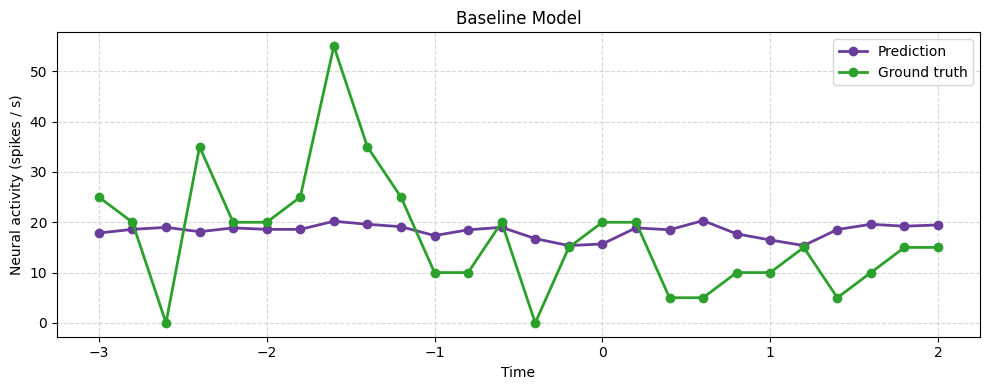

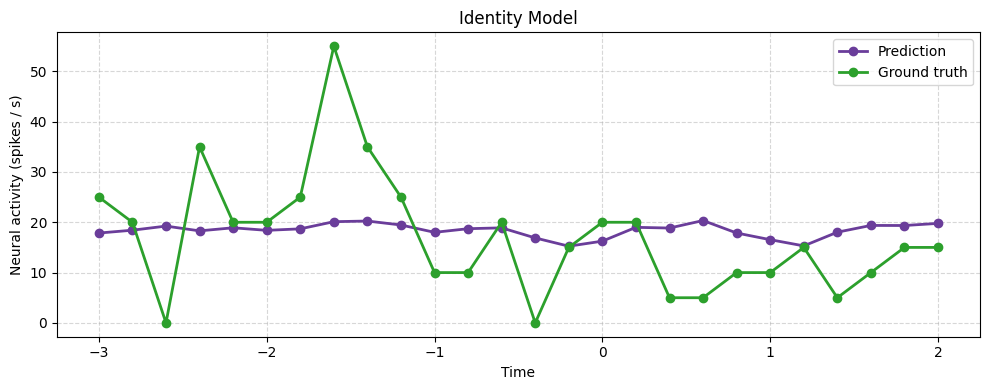

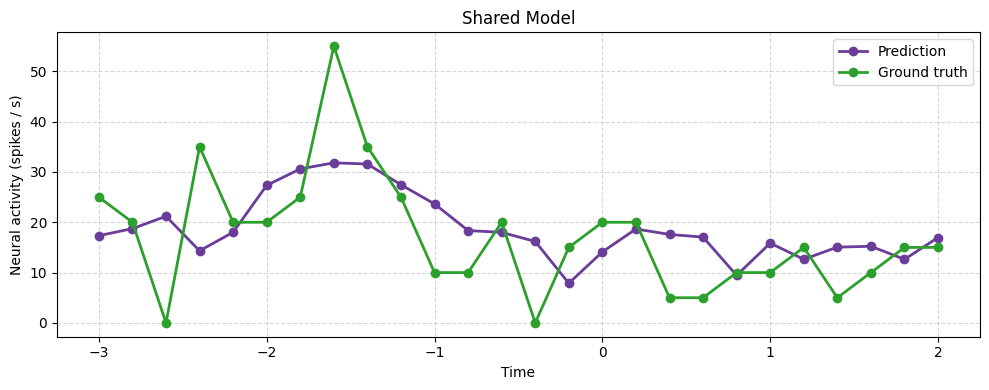

NameError: name 'temporal_Y_valid_folds' is not defined

In [28]:
plot_psth(Conf, baseline_Y_valid_folds[fold_idx][trial_idx, :, unit_idx], baseline_Y_hat_valid_folds[fold_idx][trial_idx, :, unit_idx], bin_times, title="Baseline Model", save_path="psth/baseline_model.png")
plot_psth(Conf, identity_Y_valid_folds[fold_idx][trial_idx, :, unit_idx], identity_Y_hat_valid_folds[fold_idx][trial_idx, :, unit_idx], bin_times, title="Identity Model", save_path="psth/identity_model.png")
plot_psth(Conf, shared_Y_valid_folds[fold_idx][trial_idx, :, unit_idx], shared_Y_hat_valid_folds[fold_idx][trial_idx, :, unit_idx], bin_times, title="Shared Model", save_path="psth/shared_model.png")
plot_psth(Conf, temporal_Y_valid_folds[fold_idx][trial_idx, :, unit_idx], temporal_Y_hat_valid_folds[fold_idx][trial_idx, :, unit_idx], bin_times, title="Temporal Model", save_path="psth/temporal_model.png")
plot_psth(Conf, conditional_Y_valid_folds[fold_idx][trial_idx, :, unit_idx], conditional_Y_hat_valid_folds[fold_idx][trial_idx, :, unit_idx], bin_times, title="Conditional Model", save_path="psth/conditional_model.png")
plot_psth(Conf, tempoconditional_Y_valid_folds[fold_idx][trial_idx, :, unit_idx], tempoconditional_Y_hat_valid_folds[fold_idx][trial_idx, :, unit_idx], bin_times, title="Temporal Conditional Model", save_path="psth/tempoconditional_model.png")

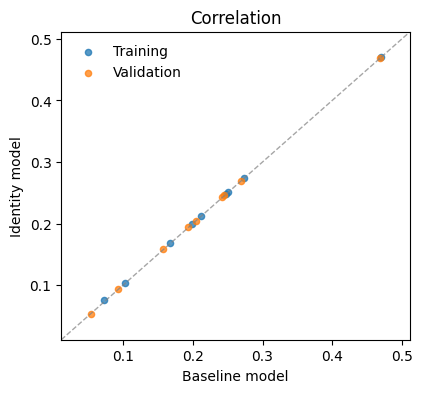

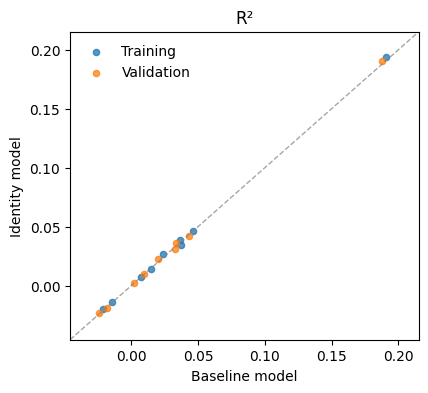

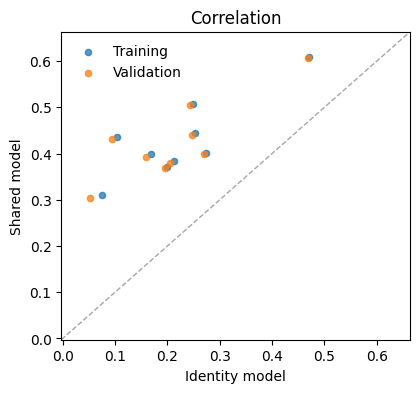

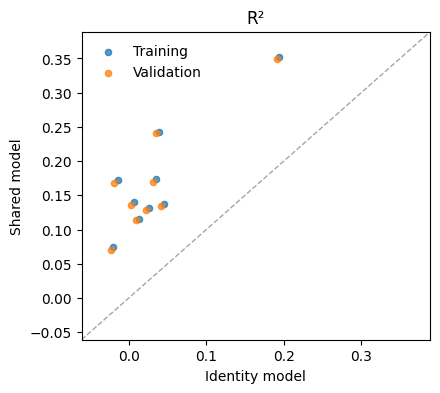

NameError: name 'temporal_corr_valid_folds' is not defined

In [37]:
plot_scatter(Conf, np.mean(baseline_corr_valid_folds, axis=0), np.mean(identity_corr_valid_folds, axis=0), np.mean(baseline_corr_train_folds, axis=0), np.mean(identity_corr_train_folds, axis=0), 'Baseline model', 'Identity model', title='Correlation', save_path='raster/corr-baseline-identity.png')
plot_scatter(Conf, np.mean(baseline_r2_valid_folds, axis=0), np.mean(identity_r2_valid_folds, axis=0), np.mean(baseline_r2_train_folds, axis=0), np.mean(identity_r2_train_folds, axis=0), 'Baseline model', 'Identity model', title='R²', save_path='raster/r2-baseline-identity.png')

plot_scatter(Conf, np.mean(identity_corr_valid_folds, axis=0), np.mean(shared_corr_valid_folds, axis=0), np.mean(identity_corr_train_folds, axis=0), np.mean(shared_corr_train_folds, axis=0), 'Identity model', 'Shared model', title='Correlation', save_path='raster/corr-identity-shared.png')
plot_scatter(Conf, np.mean(identity_r2_valid_folds, axis=0), np.mean(shared_r2_valid_folds, axis=0), np.mean(identity_r2_train_folds, axis=0), np.mean(shared_r2_train_folds, axis=0), 'Identity model', 'Shared model', title='R²', save_path='raster/r2-identity-shared.png')

plot_scatter(Conf, np.mean(shared_corr_valid_folds, axis=0), np.mean(temporal_corr_valid_folds, axis=0), np.mean(shared_corr_train_folds, axis=0), np.mean(temporal_corr_train_folds, axis=0), 'Shared model', 'Temporal model', title='Correlation', save_path='raster/corr-shared-temporal.png')
plot_scatter(Conf, np.mean(shared_r2_valid_folds, axis=0), np.mean(temporal_r2_valid_folds, axis=0), np.mean(shared_r2_train_folds, axis=0), np.mean(temporal_r2_train_folds, axis=0), 'Shared model', 'Temporal model', title='R²', save_path='raster/r2-shared-temporal.png')

plot_scatter(Conf, np.mean(shared_corr_valid_folds, axis=0), np.mean(conditional_corr_valid_folds, axis=0), np.mean(shared_corr_train_folds, axis=0), np.mean(conditional_corr_train_folds, axis=0), 'Shared model', 'Conditional model', title='Correlation', save_path='raster/corr-shared-conditional.png')
plot_scatter(Conf, np.mean(shared_r2_valid_folds, axis=0), np.mean(conditional_r2_valid_folds, axis=0), np.mean(shared_r2_train_folds, axis=0), np.mean(conditional_r2_train_folds, axis=0), 'Shared model', 'Conditional model', title='R²', save_path='raster/r2-shared-conditional.png')

plot_scatter(Conf, np.mean(shared_corr_valid_folds, axis=0), np.mean(tempoconditional_corr_valid_folds, axis=0), np.mean(shared_corr_train_folds, axis=0), np.mean(tempoconditional_corr_train_folds, axis=0), 'shared model', 'Temporal Conditional model', title='Correlation', save_path='raster/corr-shared-tempoconditional.png')
plot_scatter(Conf, np.mean(shared_r2_valid_folds, axis=0), np.mean(tempoconditional_r2_valid_folds, axis=0), np.mean(shared_r2_train_folds, axis=0), np.mean(tempoconditional_r2_train_folds, axis=0), 'shared model', 'Temporal Conditional model', title='R²', save_path='raster/r2-shared-tempoconditional.png')

plot_scatter(Conf, np.mean(temporal_corr_valid_folds, axis=0), np.mean(tempoconditional_corr_valid_folds, axis=0), np.mean(temporal_corr_train_folds, axis=0), np.mean(tempoconditional_corr_train_folds, axis=0), 'Temporal model', 'Temporal Conditional model', title='Correlation', save_path='raster/corr-temporal-tempoconditional.png')
plot_scatter(Conf, np.mean(temporal_r2_valid_folds, axis=0), np.mean(tempoconditional_r2_valid_folds, axis=0), np.mean(temporal_r2_train_folds, axis=0), np.mean(tempoconditional_r2_train_folds, axis=0), 'Temporal model', 'Temporal Conditional model', title='R²', save_path='raster/r2-temporal-tempoconditional.png')

plot_scatter(Conf, np.mean(conditional_corr_valid_folds, axis=0), np.mean(tempoconditional_corr_valid_folds, axis=0), np.mean(conditional_corr_train_folds, axis=0), np.mean(tempoconditional_corr_train_folds, axis=0), 'Conditional model', 'Temporal Conditional model', title='Correlation', save_path='raster/corr-conditional-tempoconditional.png')
plot_scatter(Conf, np.mean(conditional_r2_valid_folds, axis=0), np.mean(tempoconditional_r2_valid_folds, axis=0), np.mean(conditional_r2_train_folds, axis=0), np.mean(tempoconditional_r2_train_folds, axis=0), 'Conditional model', 'Temporal Conditional model', title='R²', save_path='raster/r2-conditional-tempoconditional.png')
